In [2]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [3]:
model = ChatAnthropic(model_name="claude-haiku-4-5-20251001")

In [4]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [6]:
def generate_joke(state: JokeState) -> JokeState:
    prompt = f"Generate a joke on the topic '{state['topic']}'."
    response = model.invoke(prompt).content

    return {'joke': response}

def generate_explanation(state: JokeState) -> JokeState:
    prompt = f"Explain the joke: {state['joke']}"
    response = model.invoke(prompt).content

    return {'explanation': response}

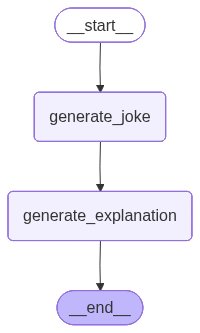

In [7]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({"topic": "pizza"}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza maker go to the bank?\n\nBecause he wanted to get his dough!',
 'explanation': '# Breaking Down the Joke\n\nThis is a **pun** that plays on double meaning:\n\n- **"Dough"** literally refers to pizza dough (the bread base)\n- **"Dough"** is also slang for money\n\nSo the joke works like this:\n- The setup makes you think about a pizza maker\'s normal work with dough\n- The punchline subverts that expectation by pivoting to the slang meaning of "dough" as money\n- A pizza maker going to a bank (a money institution) makes sense, but the reason given ("to get his dough") cleverly references both meanings simultaneously\n\nIt\'s a simple, family-friendly wordplay joke that relies on the listener catching the double meaning!'}

In [10]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to the bank?\n\nBecause he wanted to get his dough!', 'explanation': '# Breaking Down the Joke\n\nThis is a **pun** that plays on double meaning:\n\n- **"Dough"** literally refers to pizza dough (the bread base)\n- **"Dough"** is also slang for money\n\nSo the joke works like this:\n- The setup makes you think about a pizza maker\'s normal work with dough\n- The punchline subverts that expectation by pivoting to the slang meaning of "dough" as money\n- A pizza maker going to a bank (a money institution) makes sense, but the reason given ("to get his dough") cleverly references both meanings simultaneously\n\nIt\'s a simple, family-friendly wordplay joke that relies on the listener catching the double meaning!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f149405-e722-69a2-8002-728ee63c14fb'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='202

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to the bank?\n\nBecause he wanted to get his dough!', 'explanation': '# Breaking Down the Joke\n\nThis is a **pun** that plays on double meaning:\n\n- **"Dough"** literally refers to pizza dough (the bread base)\n- **"Dough"** is also slang for money\n\nSo the joke works like this:\n- The setup makes you think about a pizza maker\'s normal work with dough\n- The punchline subverts that expectation by pivoting to the slang meaning of "dough" as money\n- A pizza maker going to a bank (a money institution) makes sense, but the reason given ("to get his dough") cleverly references both meanings simultaneously\n\nIt\'s a simple, family-friendly wordplay joke that relies on the listener catching the double meaning!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f149405-e722-69a2-8002-728ee63c14fb'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='20

In [13]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({"topic": "chicken"}, config=config2)

{'topic': 'chicken',
 'joke': '# Why did the chicken go to the séance?\n\nIt wanted to talk to the other side! 🐔',
 'explanation': '# Explanation\n\nThis is a pun that plays on double meanings:\n\n1. **"The other side"** has two interpretations:\n   - In séance context: the spiritual realm / world of the dead\n   - In chicken context: the other side of the road (referencing the classic joke "Why did the chicken cross the road?")\n\n2. **The humor** comes from subverting the expectation set up by the famous joke format. You expect a joke about crossing the road, but instead get a supernatural twist where the chicken wants to communicate with spirits on "the other side."\n\nIt\'s a lighthearted joke that combines a well-known joke setup with paranormal humor and wordplay.'}

In [14]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'chicken', 'joke': '# Why did the chicken go to the séance?\n\nIt wanted to talk to the other side! 🐔', 'explanation': '# Explanation\n\nThis is a pun that plays on double meanings:\n\n1. **"The other side"** has two interpretations:\n   - In séance context: the spiritual realm / world of the dead\n   - In chicken context: the other side of the road (referencing the classic joke "Why did the chicken cross the road?")\n\n2. **The humor** comes from subverting the expectation set up by the famous joke format. You expect a joke about crossing the road, but instead get a supernatural twist where the chicken wants to communicate with spirits on "the other side."\n\nIt\'s a lighthearted joke that combines a well-known joke setup with paranormal humor and wordplay.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f149409-7f01-6f86-8002-31c83a3f9944'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_a

### Time Travel

In [22]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f149409-5bdf-6bc0-8000-bc5855759fd1"}})

StateSnapshot(values={'topic': 'chicken'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f149409-5bdf-6bc0-8000-bc5855759fd1'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-06T11:41:56.418646+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f149409-5bde-602c-bfff-c6f4e375c74e'}}, tasks=(PregelTask(id='51fdc028-a23b-dcdb-c86f-4b878758305e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': '# Why did the chicken go to the séance?\n\nIt wanted to talk to the other side! 🐔'}),), interrupts=())

In [23]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f149409-5bdf-6bc0-8000-bc5855759fd1"}})

{'topic': 'chicken',
 'joke': 'Why did the chicken go to the séance?\n\nBecause it wanted to talk to the other side! 🐔',
 'explanation': '# The Joke Explained\n\nThis is a pun that plays on the phrase **"the other side"** having two meanings:\n\n1. **Literal meaning**: In a séance (a gathering to contact spirits), "the other side" refers to the spirit world or afterlife—where dead people are believed to be.\n\n2. **Chicken meaning**: For a chicken, "the other side" could mean the literal other side of the road—famously referenced in the classic joke "Why did the chicken cross the road?"\n\nSo the humor comes from the setup making you expect a séance joke, but the punchline subverts that by suggesting the chicken just wants to communicate with... the road. It\'s a lighthearted misdirection that combines two well-known comedy traditions.'}

In [24]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'chicken', 'joke': 'Why did the chicken go to the séance?\n\nBecause it wanted to talk to the other side! 🐔', 'explanation': '# The Joke Explained\n\nThis is a pun that plays on the phrase **"the other side"** having two meanings:\n\n1. **Literal meaning**: In a séance (a gathering to contact spirits), "the other side" refers to the spirit world or afterlife—where dead people are believed to be.\n\n2. **Chicken meaning**: For a chicken, "the other side" could mean the literal other side of the road—famously referenced in the classic joke "Why did the chicken cross the road?"\n\nSo the humor comes from the setup making you expect a séance joke, but the punchline subverts that by suggesting the chicken just wants to communicate with... the road. It\'s a lighthearted misdirection that combines two well-known comedy traditions.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f149414-ae59-6152-8003-929163665f5c'}

#### Updating State

In [27]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f149409-5bdf-6bc0-8000-bc5855759fd1", "checkpoint_ns": ""}}, {"topic": "samosa"})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14941c-ab5a-6322-8001-406dab149d45'}}

In [28]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f14941c-ab5a-6322-8001-406dab149d45'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-06T11:50:34.779916+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f149409-5bdf-6bc0-8000-bc5855759fd1'}}, tasks=(PregelTask(id='7a320029-6e92-1dc4-3c5a-e89c2690a5b0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'chicken', 'joke': 'Why did the chicken go to the séance?\n\nBecause it wanted to talk to the other side! 🐔', 'explanation': '# The Joke Explained\n\nThis is a pun that plays on the phrase **"the other side"** having two meanings:\n\n1. **Literal meaning**: In a séance (a gathering to contact spirits), "the other side" refers to the spirit world 

In [29]:
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f14941c-ab5a-6322-8001-406dab149d45"}})

{'topic': 'samosa',
 'joke': '# The Samosa Joke\n\nWhy did the samosa go to therapy?\n\nBecause it had too many *layers* of emotional baggage! 🥟\n\n---\n\n*Bonus version:* Why did the samosa break up with the chutney? Because their relationship was too *fried* and emotional!',
 'explanation': '# Breaking Down the Joke\n\n## Main Joke\nThe humor works through **wordplay on "layers"**:\n\n- **Literal meaning**: Samosas are made with multiple layers of pastry dough\n- **Figurative meaning**: "Layers of emotional baggage" is a common therapy phrase meaning unresolved psychological issues\n\nThe joke creates a pun by treating a physical characteristic of the food as if it were an emotional problem requiring therapy.\n\n## Bonus Joke\nThis uses similar wordplay:\n\n- **"Fried"** can mean:\n  - The cooking method (samosas are deep-fried)\n  - Slang for burnt out/stressed/exhausted\n  - A relationship that\'s "fried" = ruined/broken\n\nSo it\'s joking that their relationship literally fell apa

In [30]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': '# The Samosa Joke\n\nWhy did the samosa go to therapy?\n\nBecause it had too many *layers* of emotional baggage! 🥟\n\n---\n\n*Bonus version:* Why did the samosa break up with the chutney? Because their relationship was too *fried* and emotional!', 'explanation': '# Breaking Down the Joke\n\n## Main Joke\nThe humor works through **wordplay on "layers"**:\n\n- **Literal meaning**: Samosas are made with multiple layers of pastry dough\n- **Figurative meaning**: "Layers of emotional baggage" is a common therapy phrase meaning unresolved psychological issues\n\nThe joke creates a pun by treating a physical characteristic of the food as if it were an emotional problem requiring therapy.\n\n## Bonus Joke\nThis uses similar wordplay:\n\n- **"Fried"** can mean:\n  - The cooking method (samosas are deep-fried)\n  - Slang for burnt out/stressed/exhausted\n  - A relationship that\'s "fried" = ruined/broken\n\nSo it\'s joking that their relationshi

### Fault Tolerance

In [34]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [35]:
class CrashState(TypedDict):
    input: str
    step1_status: str
    step2_status: str
    step_3_status: str

In [36]:
def step_1(state: CrashState) -> CrashState:
    print("Executing Step 1...")
    return {"step1_status": "done"}

def step_2(state: CrashState) -> CrashState:
    print("Executing Step 2...")
    time.sleep(30)
    return {"step2_status": "done"}

def step_3(state: CrashState) -> CrashState:
    print("Executing Step 3...")
    return {"step3_status": "done"}

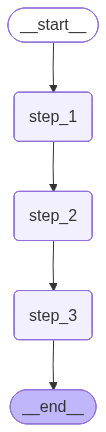

In [37]:
graph = StateGraph(CrashState)
graph.add_node("step_1", step_1)
graph.add_node("step_2", step_2)
graph.add_node("step_3", step_3)

graph.set_entry_point("step_1")
graph.add_edge("step_1", "step_2")
graph.add_edge("step_2", "step_3")
graph.add_edge("step_3", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

workflow

In [39]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    workflow.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
Executing Step 1...
Executing Step 2...
❌ Kernel manually interrupted (crash simulated).


In [40]:
# re-running for fault tolerance
print("Re-running graph for fault tolerance...")
final_state_grpah = workflow.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("Final State after recovery:", final_state_grpah)

Re-running graph for fault tolerance...
Executing Step 2...
Executing Step 3...
Final State after recovery: {'input': 'start', 'step1_status': 'done', 'step2_status': 'done'}
